<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/Don%20Eleazar%20T.%20Fernandez%2C%20CPE32S3%2C%20CPE%20313%20(Hands-on%20Activity%208.2%20-%20Topic%20Modeling).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

In [3]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [5]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [6]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [7]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [8]:
with open('/content/drive/MyDrive/CPE 313/NLP/ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [9]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [10]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [12]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [13]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [14]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

**Synthesis:**  The document was loaded and processed so that important context stays. Next, the text is converted into numbers using n‑grams, which capture single pair words to give the model more context. Then, LDA is applied to group words into topics, which shows words of same context appear together. After that, the topics are displayed with their important words, and labels can be added to make them easier to understand. Lastly, the model is tested with different numbers of topics to see which setup separates better the categories in the dataset.

## Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset

In [22]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CPE 313/H.O.A. 8.2/train.csv').sample(500, random_state=42)
df.head()

,Class Index,Title,Description
71787,3,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,..."
67218,3,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...
54066,2,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...
7168,4,Flying the Sun to Safety,When the Genesis capsule comes back to Earth w...
29618,3,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to ...


In [23]:
df['text'] = df['Title'] + " " + df['Description']
docs = df['text'].astype(str).tolist()

In [34]:
import re

clean_docs = []

for doc in docs:
    doc = doc.lower() # lowercase
    doc = re.sub(r'[^a-z\s]', ' ', doc) # remove numbers & punctuation
    doc = re.sub(r'\s+', ' ', doc) # remove extra spaces
    clean_docs.append(doc)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(clean_docs)

In [53]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 4
n_iter = 20

lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00470958, 0.98583316, 0.0046992 , 0.00475806])

In [54]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda, count_vectorizer.get_feature_names_out(), 20)


Topic  0
gt, lt, reuters, lt gt, new, said, fullquote, ap, new york, york, stocks, gt lt, com, president, ticker, href http, lt href, href, http, www

Topic  1
said, reuters, new, ap, oil, space, friday, search, year, google, canadian, today, economy, years, world, tokyo, record, corp, yesterday, stocks

Topic  2
quot, minister, said, service, iraq, afp, music, yesterday, election, williams, british, prime, prime minister, new, linux, security, apple, microsoft, european, president

Topic  3
ap, game, year, reuters, ap ap, million, new, said, tuesday, medal, athens, coach, second, gold, season, games, olympics, states, united states, united


In [55]:
tn = ["World Politics or International News", "Sports or Games", "Business or Economy or Finance", "Technology or Science"]

display_topics(lda, count_vectorizer.get_feature_names_out(), 20, topic_names=tn)


Topic: ' World Politics or International News '
gt, lt, reuters, lt gt, new, said, fullquote, ap, new york, york, stocks, gt lt, com, president, ticker, href http, lt href, href, http, www

Topic: ' Sports or Games '
said, reuters, new, ap, oil, space, friday, search, year, google, canadian, today, economy, years, world, tokyo, record, corp, yesterday, stocks

Topic: ' Business or Economy or Finance '
quot, minister, said, service, iraq, afp, music, yesterday, election, williams, british, prime, prime minister, new, linux, security, apple, microsoft, european, president

Topic: ' Technology or Science '
ap, game, year, reuters, ap ap, million, new, said, tuesday, medal, athens, coach, second, gold, season, games, olympics, states, united states, united


In [56]:
import numpy as np

data = lda.fit_transform(X)
dominant_topics = np.argmax(data, axis=1)

topic_docs = {}

for i, topic in enumerate(dominant_topics):
    if topic not in topic_docs:
        topic_docs[topic] = []
    topic_docs[topic].append(i)

In [57]:
for topic, doc_ids in topic_docs.items():
    print("\n========================")
    print("Topic:", topic, "-", tn[topic])
    print("========================")

    for doc_id in doc_ids[:2]:
        print("\n--- Example Document ---\n")
        print(docs[doc_id][:500])


Topic: 1 - Sports or Games

--- Example Document ---

BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.

--- Example Document ---

Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 10-year career.

Topic: 0 - World Politics or International News

--- Example Document ---

Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos.

--- Example Document ---

Stocks Seen Flat as Nortel and Oil Weigh  NEW YORK (Reuters) - U.S. stocks were set to open near  unchanged on Thursday after a warning from technology  bellwether Nortel Networks Corp.

In [58]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X)

kmeans = KMeans(n_clusters=n_topics, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_reduced)

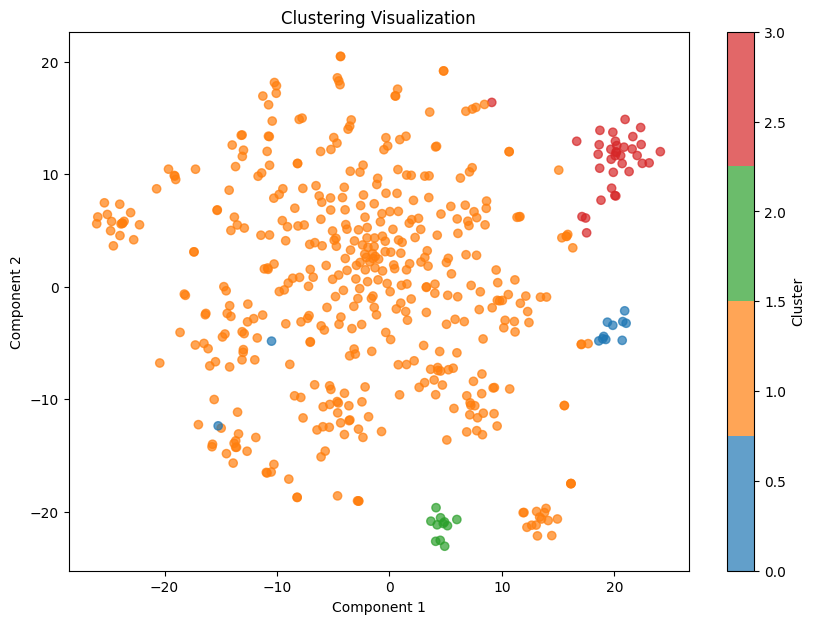

In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10,7))

cmap = mcolors.ListedColormap(plt.cm.tab10.colors[:4])

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=clusters,
    cmap=cmap,
    alpha=0.7
)

plt.title("Clustering Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.show()

**Analysis:** The process begins by cleaning and preparing the data so that only meaningful words remain, removing numbers, punctuation, and common stop words. Then the documents are converted into a numerical format using a vectorizer. After that, LDA is applied to group the words into a set number of topics, each represented by its most frequent terms. The model then assigns labels to those topics, making them easier to interpret. Lastly, the output shows which documents belong to each topic, along with sample text.

## Conclusion

In this laboratory activity, I learned how to clean text and use LDA. I began with removing unnecessary words, turning text into numbers (which made the processing of data possible), and running LDA to group related words together. Then the model formed clear topics, and matched documents to them.